# Unit 1 · Introduction

Course: **21CSC305P — Machine Learning**

## Aim
Read real traffic data, understand vehicle count and temperature, and draw simple graphs.

## Assignment tasks
1. Devise a program to import, load and view dataset.
2. Create a program to display the summary and statistics of the dataset.

## About this transport dataset
This is **real hourly road-sensor data** from westbound Interstate 94 between Minneapolis and Saint Paul, USA. A road sensor counts vehicles passing during each hour. We use **1,008 consecutive hours (42 days), from 13 April 2017 at 10:00 to 25 May 2017 at 09:00**, in the source's local timestamps.

**traffic_volume**: vehicles counted in that hour. **temperature_c**: air temperature in degrees Celsius. **date_time** identifies the hour and is not a numerical model feature.

The original dataset has 48,204 rows and includes weather and holidays from 2012–2018. Repeated weather descriptions can share a timestamp; their traffic counts were verified identical before keeping the first entry. The teaching CSV uses the first six weeks of the longest continuous hourly sequence. Temperature was converted from Kelvin by subtracting 273.15. No missing hours were filled and no measurements were invented.

Source: [UCI Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume). Citation: Hogue, J. (2019), DOI: 10.24432/C5X60B. License: CC BY 4.0. The complete original compressed CSV is included.

**What to tell faculty:** “I am studying traffic patterns using real vehicle counts from a highway sensor.” High vehicle count means a busy hour; without speed or capacity data it does not prove congestion. This small window is a classroom demonstration, not a validation across roads or seasons.

Run cells from top to bottom. Keep the `data` folder beside `notebooks`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Run from the project folder or from its notebooks folder.
try:
    df = pd.read_csv('data/traffic.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/traffic.csv')

df['date_time'] = pd.to_datetime(df['date_time'])
print('Number of traffic hours:', len(df))

Number of traffic hours: 1008


## Experiment 1 · Read and view
`head()` shows the first five rows. `shape` gives the number of rows and columns. Each row is one hour; numeric columns measure vehicle count and air temperature.

In [2]:
display(df.head())
print('Rows and columns:', df.shape)
print('Missing values:')
print(df.isna().sum())

,date_time,traffic_volume,temperature_c
0,2017-04-13 10:00:00,4576,8.26
1,2017-04-13 11:00:00,5033,8.75
2,2017-04-13 12:00:00,5138,9.00
3,2017-04-13 13:00:00,5296,9.19
4,2017-04-13 14:00:00,5400,10.26


Rows and columns: (1008, 3)
Missing values:
date_time         0
traffic_volume    0
temperature_c     0
dtype: int64


## Experiment 2 · Summary statistics
`describe()` gives count, mean, standard deviation, minimum, quartiles and maximum. The mean is the average; the median is the middle value.

,date_time,traffic_volume,temperature_c
count,1008,1008.00,1008.00
mean,2017-05-04 09:30:00,3475.98,11.73
min,2017-04-13 10:00:00,233.00,-0.20
25%,2017-04-23 21:45:00,1374.75,7.80
50%,2017-05-04 09:30:00,3862.50,11.14
75%,2017-05-14 21:15:00,5093.25,15.93
max,2017-05-25 09:00:00,7126.00,27.74
std,NaN,2023.54,5.68


Average traffic volume: 3475.98 vehicles/hour
Median air temperature: 11.14 degrees C


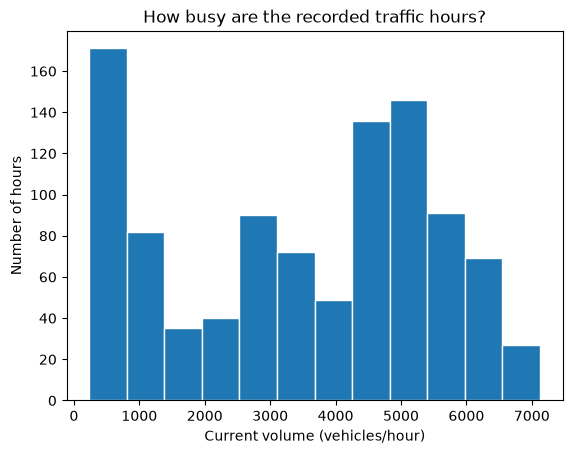

In [3]:
display(df.describe().round(2))
print('Average traffic volume:', round(df['traffic_volume'].mean(), 2), 'vehicles/hour')
print('Median air temperature:', round(df['temperature_c'].median(), 2), 'degrees C')

plt.hist(df['traffic_volume'], bins=12, edgecolor='white')
plt.xlabel('Current volume (vehicles/hour)')
plt.ylabel('Number of hours')
plt.title('How busy are the recorded traffic hours?')
plt.show()

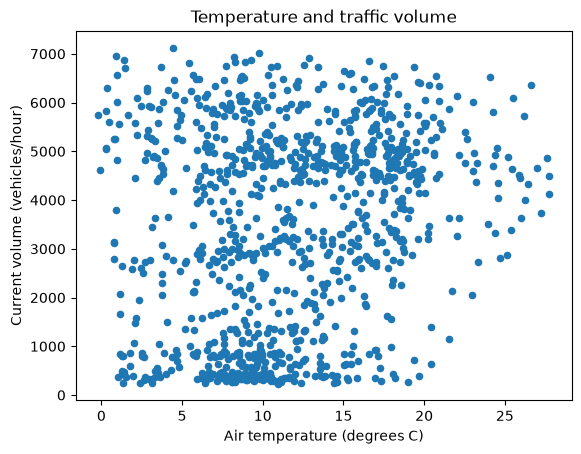

In [4]:
plt.scatter(df['temperature_c'], df['traffic_volume'], s=20)
plt.xlabel('Air temperature (degrees C)')
plt.ylabel('Current volume (vehicles/hour)')
plt.title('Temperature and traffic volume')
plt.show()

## What to explain
A histogram counts observations in ranges. A scatter plot draws one dot for each row. Read the graphs before making a claim about the relationship.

**Try:** Change `bins=12` to `bins=6`.

**Viva:** What does one row represent? How do mean and median differ?